**after adding extra data**

In [ ]:
weekly_data.to_excel("dengue_week_data_final.xlsx", index=False)

NameError: name 'weekly_data' is not defined

### openning the file

In [ ]:
import pandas as pd
w1=pd.read_excel('dengue_week_data_final.xlsx')

In [ ]:
w1.head()

,state,week,year,cases,rainfall,humidity,temperature,risk_level,risk_level_encoded,WaterLogging_minimal_pc,WaterLogging_substantial_pc,hygiene_total,un-hygiene_total,hygiene_ratio,rainfall_x_humidity,rainfall_lag1
0,Andhra Pradesh,18,2019,6,0.3,45.750000,34.95,Low,1,81.3,18.7,98.3,1.7,36.407407,13.725000,6.85315
1,Andhra Pradesh,23,2019,14,0.0,77.875000,31.50,Low,1,81.3,18.7,98.3,1.7,36.407407,0.000000,0.30000
2,Andhra Pradesh,34,2022,4,6.2,59.125000,31.35,Low,1,81.3,18.7,98.3,1.7,36.407407,366.575000,0.00000
3,Arunachal Pradesh,23,2019,183,9.6,78.458333,27.85,High,0,100.0,0.0,100.0,0.0,100.000000,753.200000,6.20000
4,Arunachal Pradesh,25,2019,316,13.7,85.416667,28.05,High,0,100.0,0.0,100.0,0.0,100.000000,1170.208333,9.60000


In [ ]:
w1.dtypes

,0
state,object
week,int64
year,int64
cases,int64
rainfall,float64
humidity,float64
temperature,float64
risk_level,object
risk_level_encoded,int64
WaterLogging_minimal_pc,float64


In [ ]:
import numpy as np

def generate_data(data, target_var, n_rows, noise_lvl=0.1):
    base = data[data['risk_level'] == target_var].copy()
    samp= base.sample(n=n_rows, replace=True).reset_index(drop=True) #sample randomly pick rowsfrom base

    num_cols=samp.select_dtypes(include=['float64', 'int64']).columns #identifying numerical columns
    noise=np.random.normal(0, noise_lvl, samp[num_cols].shape)
    samp[num_cols] += noise #adding noise to each numeric columns
    samp['risk_level'] = target_var #assigning risk level
    return samp

# Generate synthetic Medium ,low and High risk samples
generate_medium = generate_data(w1, 'Medium',175)
generate_high = generate_data(w1, 'High',173)
generate_low = generate_data(w1, 'Low', 167)


# Combine with original
balanced_data=pd.concat([w1, generate_medium, generate_high,generate_low], ignore_index=True)

# Encode
label_mapping = {'High': 0,'Low': 1,'Medium': 2}
balanced_data['risk_level_encoded'] = balanced_data['risk_level'].map(label_mapping)

grouped = balanced_data.groupby(['state','year', 'week'], as_index=False).agg({
    'rainfall': 'mean',
    'humidity': 'mean',
    'temperature': 'mean',
    'hygiene_total': 'sum',
    'un-hygiene_total': 'sum',
    'risk_level_encoded': lambda x: x.mode()[0],
    'risk_level': lambda x: x.mode()[0]  # keep label column too
})
# Save to Excel
balanced_data.to_excel("balanced_week6_dengue_data_final.xlsx", index=False)
print("✅ Data generated and saved as 'balanced_dengue_data_final.xlsx'")


✅ Data generated and saved as 'balanced_dengue_data_final.xlsx'


In [ ]:
print(balanced_data[['risk_level', 'risk_level_encoded']].drop_duplicates())


  risk_level  risk_level_encoded
0        Low                   1
3       High                   0
5     Medium                   2


lets predict the value on this balaced data

In [ ]:
import pandas as pd
bal_data=pd.read_excel('balanced_week6_dengue_data_final.xlsx')

In [ ]:
bal_data['risk_level'].value_counts()

,count
risk_level,
Low,300
High,300
Medium,300


In [ ]:
bal_data.head()

,state,week,year,cases,rainfall,humidity,temperature,risk_level,risk_level_encoded,WaterLogging_minimal_pc,WaterLogging_substantial_pc,hygiene_total,un-hygiene_total,hygiene_ratio,rainfall_x_humidity,rainfall_lag1
0,Andhra Pradesh,18.0,2019.0,6.0,0.3,45.750000,34.95,Low,1,81.3,18.7,98.3,1.7,36.407407,13.725000,6.85315
1,Andhra Pradesh,23.0,2019.0,14.0,0.0,77.875000,31.50,Low,1,81.3,18.7,98.3,1.7,36.407407,0.000000,0.30000
2,Andhra Pradesh,34.0,2022.0,4.0,6.2,59.125000,31.35,Low,1,81.3,18.7,98.3,1.7,36.407407,366.575000,0.00000
3,Arunachal Pradesh,23.0,2019.0,183.0,9.6,78.458333,27.85,High,0,100.0,0.0,100.0,0.0,100.000000,753.200000,6.20000
4,Arunachal Pradesh,25.0,2019.0,316.0,13.7,85.416667,28.05,High,0,100.0,0.0,100.0,0.0,100.000000,1170.208333,9.60000


**adding season**

In [ ]:
def get_season(w):
    if 10 <= w <= 22:
        return 'Summer'
    elif 23 <= w <= 35:
        return 'Monsoon'
    elif 36 <= w <= 47:
        return 'Post-Monsoon'
    else:
        return 'Winter'

bal_data['season'] = bal_data['week'].apply(get_season)


In [ ]:
bal_data = pd.get_dummies(bal_data, columns=['season'], drop_first=True)


In [ ]:
bal_data.duplicated(subset=['rainfall', 'humidity', 'temperature'], keep=False).sum()


np.int64(2)

In [ ]:
bal_data.duplicated(subset=['rainfall', 'humidity', 'temperature', 'hygiene_total', 'un-hygiene_total'], keep=False).sum()


np.int64(0)

In [ ]:
bal_data.isnull().sum()

,0
state,0
week,0
year,0
cases,0
rainfall,0
humidity,0
temperature,0
risk_level,0
risk_level_encoded,0
WaterLogging_minimal_pc,0


In [ ]:
bal_data.head()

,state,week,year,cases,rainfall,humidity,temperature,risk_level,risk_level_encoded,WaterLogging_minimal_pc,WaterLogging_substantial_pc,hygiene_total,un-hygiene_total,hygiene_ratio,rainfall_x_humidity,rainfall_lag1,season_Post-Monsoon,season_Summer,season_Winter
0,Andhra Pradesh,18.0,2019.0,6.0,0.3,45.750000,34.95,Low,1,81.3,18.7,98.3,1.7,36.407407,13.725000,6.85315,False,True,False
1,Andhra Pradesh,23.0,2019.0,14.0,0.0,77.875000,31.50,Low,1,81.3,18.7,98.3,1.7,36.407407,0.000000,0.30000,False,False,False
2,Andhra Pradesh,34.0,2022.0,4.0,6.2,59.125000,31.35,Low,1,81.3,18.7,98.3,1.7,36.407407,366.575000,0.00000,False,False,False
3,Arunachal Pradesh,23.0,2019.0,183.0,9.6,78.458333,27.85,High,0,100.0,0.0,100.0,0.0,100.000000,753.200000,6.20000,False,False,False
4,Arunachal Pradesh,25.0,2019.0,316.0,13.7,85.416667,28.05,High,0,100.0,0.0,100.0,0.0,100.000000,1170.208333,9.60000,False,False,False


In [ ]:
bal_data['waterlogging_ratio']=bal_data['WaterLogging_substantial_pc'] / (bal_data['WaterLogging_minimal_pc'] + 1)

separating features from target

In [ ]:
import pandas as pd
bal_data=pd.read_excel('balanced_week7_dengue_data_final.xlsx')

In [ ]:
X = bal_data.drop(columns=['risk_level', 'risk_level_encoded', 'cases','WaterLogging_minimal_pc','un-hygiene_total','waterlogging_ratio','rainfall_lag1'])
y = bal_data['risk_level_encoded']

agar mei rainfall_lag1 htati hun to smote ki accuracy(random state=39,40) se 0.83 jaari hai and (random state 50) se 0.85 aari hai

In [ ]:
X.columns

Index(['state', 'week', 'year', 'rainfall', 'humidity', 'temperature',
       'WaterLogging_substantial_pc', 'hygiene_total', 'hygiene_ratio',
       'rainfall_x_humidity', 'season_Post-Monsoon', 'season_Summer',
       'season_Winter'],
      dtype='object')

In [ ]:
X['state']=X['state'].str.strip()

In [ ]:
# Save to Excel
bal_data.to_excel("balanced_week7_dengue_data_final.xlsx", index=False)
print("✅ Data generated and saved as 'balanced_dengue_data_final.xlsx'")


✅ Data generated and saved as 'balanced_dengue_data_final.xlsx'


train test split

phle 42 thi

In [ ]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
y_train3=y_train2.copy()

In [ ]:
X_train2.columns

Index(['state', 'week', 'year', 'rainfall', 'humidity', 'temperature',
       'WaterLogging_substantial_pc', 'hygiene_total', 'hygiene_ratio',
       'rainfall_x_humidity', 'season_Post-Monsoon', 'season_Summer',
       'season_Winter'],
      dtype='object')

In [ ]:
X_train2['state'].nunique()

32

In [ ]:
X_test2['state'].unique()

array(['Uttarakhand', 'Tamil Nadu', 'Maharashtra', 'Karnataka',
       'Karnatka', 'Madhya Pradesh', 'Rajasthan', 'Kerala', 'Goa',
       'Haryana', 'Jammu & Kashmir', 'Jharkhand', 'Sikkim',
       'Uttar Pradesh', 'Nagaland', 'Manipur', 'Bihar',
       'Arunachal Pradesh', 'Puducherry', 'Tripura', 'Mizoram',
       'West Bengal', 'Assam', 'Chhattisgarh', 'Andhra Pradesh',
       'Telangana', 'Gujarat', 'Chandigarh'], dtype=object)

In [ ]:
X_train2['state'].nunique()

32

columns transformenr(onehot)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

col_trans = ColumnTransformer([
    ('state_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ['state'])
], remainder='passthrough')

X_train_trans2 = col_trans.fit_transform(X_train2)
X_test_trans2 = col_trans.transform(X_test2)


In [ ]:
X_train_trans2.shape

(630, 43)

logistic regression

In [ ]:
X_test_trans2.shape

(270, 43)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=3000)
clf.fit(X_train_trans2, y_train2)
y_pred_bal = clf.predict(X_test_trans2)

print(classification_report(y_test2, y_pred_bal))


              precision    recall  f1-score   support

           0       0.42      0.50      0.46        90
           1       0.41      0.27      0.32        90
           2       0.45      0.53      0.49        90

    accuracy                           0.43       270
   macro avg       0.43      0.43      0.42       270
weighted avg       0.43      0.43      0.42       270



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test2, y_pred_bal))


              precision    recall  f1-score   support

           0       0.42      0.50      0.46        90
           1       0.41      0.27      0.32        90
           2       0.45      0.53      0.49        90

    accuracy                           0.43       270
   macro avg       0.43      0.43      0.42       270
weighted avg       0.43      0.43      0.42       270



using SMOTE

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test2, y_pred_cb))
print("Report:\n", classification_report(y_test2, y_pred_cb))


NameError: name 'y_pred_cb' is not defined

koshish to make it better

**bhot acha result aaya hai**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

phle random state 38 thi

## final model used

In [ ]:
smote = SMOTE(random_state=42)
X_resampled2, y_resampled2= smote.fit_resample(X_train_trans2, y_train2)  #apply SMOTE to training set only
#training model
model = RandomForestClassifier(random_state=50)
model.fit(X_resampled2, y_resampled2)
#evaluating
y_pred_rand2 = model.predict(X_test_trans2)
print(classification_report(y_test2, y_pred_rand2))


              precision    recall  f1-score   support

           0       0.85      0.79      0.82        90
           1       0.84      0.89      0.86        90
           2       0.86      0.87      0.86        90

    accuracy                           0.85       270
   macro avg       0.85      0.85      0.85       270
weighted avg       0.85      0.85      0.85       270



In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test2, y_pred_rand2))

[[71 10  9]
 [ 6 80  4]
 [ 7  5 78]]


In [ ]:

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=50)
model.fit(X_resampled2, y_resampled2)
#evaluating
y_pred_rand2 = model.predict(X_test_trans2)
print(classification_report(y_test2, y_pred_rand2))



              precision    recall  f1-score   support

           0       0.69      0.68      0.69        90
           1       0.77      0.72      0.75        90
           2       0.73      0.80      0.77        90

    accuracy                           0.73       270
   macro avg       0.73      0.73      0.73       270
weighted avg       0.73      0.73      0.73       270



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=3000)
clf.fit(X_resampled2, y_resampled2)
y_pred_bal = clf.predict(X_test_trans2)

print(classification_report(y_test2, y_pred_bal))


              precision    recall  f1-score   support

           0       0.42      0.50      0.46        90
           1       0.41      0.27      0.32        90
           2       0.45      0.53      0.49        90

    accuracy                           0.43       270
   macro avg       0.43      0.43      0.42       270
weighted avg       0.43      0.43      0.42       270



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
svm_model = SVC(kernel='poly', random_state=42)
svm_model.fit(X_resampled2, y_resampled2)
y_pred = svm_model.predict(X_test_trans2)
accuracy = accuracy_score(y_test2, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test2, y_pred))

Accuracy: 0.36666666666666664
              precision    recall  f1-score   support

           0       0.42      0.31      0.36        90
           1       0.17      0.01      0.02        90
           2       0.35      0.78      0.49        90

    accuracy                           0.37       270
   macro avg       0.31      0.37      0.29       270
weighted avg       0.31      0.37      0.29       270



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_resampled2, y_resampled2)

# Predict
y_pred = xgb_model.predict(X_test_trans2)

# Evaluate
accuracy = accuracy_score(y_test2, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test2, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:54:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7074074074074074
              precision    recall  f1-score   support

           0       0.71      0.64      0.67        90
           1       0.69      0.80      0.74        90
           2       0.73      0.68      0.70        90

    accuracy                           0.71       270
   macro avg       0.71      0.71      0.71       270
weighted avg       0.71      0.71      0.71       270



using cross validation

**saving this model**

In [ ]:

import joblib

# Suppose this is your best model
joblib.dump(model1, 'best_dengue_weekly_model4_final.pkl')
print("✅ Model saved successfully.")

✅ Model saved successfully.


In [ ]:
joblib.dump(col_trans, 'col_trans.pkl')

['col_trans.pkl']

In [ ]:
loaded_model = joblib.load('best_dengue_weekly_model4_final.pkl')

# Use it to predict
pred = loaded_model.predict(X_test_trans2)

In [ ]:
feature_list = list(X.columns)
joblib.dump(feature_list, 'feature_list.pkl')

['feature_list.pkl']

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

In [ ]:
pipeline = Pipeline([
    ('preprocessor', col_trans),
    ('model', model1)
])

In [ ]:
joblib.dump(pipeline, 'dengue_model_pipeline.pkl')
print("saves success")

saves success


In [ ]:
import pickle

with open('dengue_pipeline2.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

## plotting important features

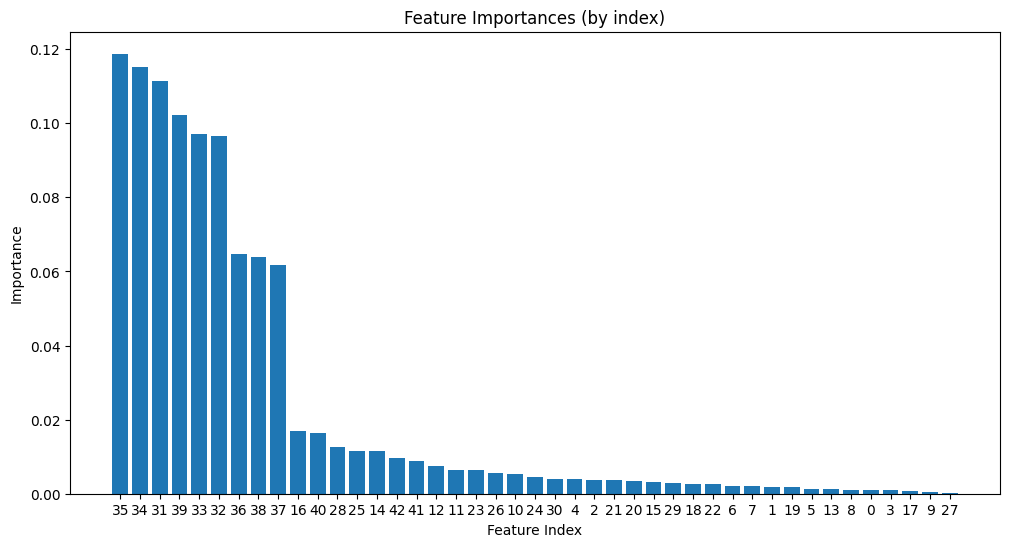

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = model1.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

# Plot
plt.figure(figsize=(12,6))
plt.title("Feature Importances (by index)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(ticks=range(len(importances)), labels=indices)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()


In [ ]:
feature_names = col_trans.get_feature_names_out()

In [ ]:
feature_names

array(['state_ohe__state_Arunachal Pradesh', 'state_ohe__state_Assam',
       'state_ohe__state_Bihar', 'state_ohe__state_Chandigarh',
       'state_ohe__state_Chhattisgarh', 'state_ohe__state_Delhi',
       'state_ohe__state_Goa', 'state_ohe__state_Gujarat',
       'state_ohe__state_Haryana', 'state_ohe__state_Himachal Pradesh',
       'state_ohe__state_Jammu & Kashmir', 'state_ohe__state_Jharkhand',
       'state_ohe__state_Karnataka', 'state_ohe__state_Karnatka',
       'state_ohe__state_Kerala', 'state_ohe__state_Madhya Pradesh',
       'state_ohe__state_Maharashtra', 'state_ohe__state_Manipur',
       'state_ohe__state_Meghalaya', 'state_ohe__state_Mizoram',
       'state_ohe__state_Nagaland', 'state_ohe__state_Puducherry',
       'state_ohe__state_Punjab', 'state_ohe__state_Rajasthan',
       'state_ohe__state_Sikkim', 'state_ohe__state_Tamil Nadu',
       'state_ohe__state_Telangana', 'state_ohe__state_Tripura',
       'state_ohe__state_Uttar Pradesh', 'state_ohe__state_Uttarakh

In [ ]:
indices = [34,35, 31, 39, 32, 33, 38, 36, 37]

print("Selected Features:")
print(", ".join([f"{i}: {feature_names[i]}" for i in indices]))

Selected Features:
34: remainder__humidity, 35: remainder__temperature, 31: remainder__week, 39: remainder__rainfall_x_humidity, 32: remainder__year, 33: remainder__rainfall, 38: remainder__hygiene_ratio, 36: remainder__WaterLogging_substantial_pc, 37: remainder__hygiene_total


In [ ]:
model2 = RandomForestClassifier(random_state=50)
model2.fit(X_train_trans2, y_train2)
#evaluating
y_pred_rand3 = model2.predict(X_test_trans2)
print(classification_report(y_test2, y_pred_rand3))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82        90
           1       0.84      0.89      0.86        90
           2       0.86      0.87      0.86        90

    accuracy                           0.85       270
   macro avg       0.85      0.85      0.85       270
weighted avg       0.85      0.85      0.85       270



## cross validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model2, X_train_trans2, y_train2, cv=10,scoring='accuracy').mean()

print("cross_val_score",scores)

cross_val_score 0.7587301587301587


In [ ]:
print("cross_val_score with stratified kfolds",scores2)

cross_val_score with stratified kfolds [0.76190476 0.80952381 0.76190476 0.80952381 0.84126984 0.82539683
 0.77777778 0.77777778 0.73015873 0.73015873]


K folds

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores1 = cross_val_score(model2, X_train_trans2, y_train2, cv=kf, scoring='accuracy')
print("Mean accuracy with Kfolds:", scores1.mean())


Mean accuracy with Kfolds: 0.7587301587301587


Stratified Kfolds

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores2 = cross_val_score(model2, X_train_trans2, y_train2, cv=skf, scoring='accuracy')
print("Mean CV Accuracy with stratified Kfolds:", scores2.mean())


Mean CV Accuracy with stratified Kfolds: 0.7825396825396826


In [ ]:
print("cross_val_score",scores)
print("Mean accuracy with Kfolds:", scores1.mean())
print("Mean CV Accuracy with stratified Kfolds:", scores2.mean())

cross_val_score 0.7587301587301587
Mean accuracy with Kfolds: 0.7746031746031745
Mean CV Accuracy with stratified Kfolds: 0.7825396825396826


In [ ]:
print("Mean CV Accuracy with stratified Kfolds:", scores2.mean())

Mean CV Accuracy with stratified Kfolds: 0.7825396825396826
